# XGBoost CPU `pred_contribs` vs Metal GPU

Both engines compute **exact TreeSHAP** for the same model, so this is a pure
performance comparison with a built-in correctness check.

**Methodology** (mirrors the repository's benchmark harnesses):

- one model, trained once; one explainer, compiled once;
- the engines run **paired and interleaved in randomized order** within each
  iteration, so clock/thermal drift hits all engines equally;
- one warmup round per configuration, then medians over the timed iterations, with
  every raw sample shown in the chart;
- `DMatrix` construction is excluded from the CPU timing (built once per size), and
  the GPU consumes the same float32 array.

> **Caveat:** absolute numbers are device- and thermal-state-specific (this run:
> the committed outputs come from an Apple M4 Max). Paired ratios measured *within*
> this notebook are meaningful; comparing absolute times across machines or sessions
> is not. The repository's `benchmarks/` harnesses are the rigorous version of this
> notebook.

In [1]:
import os
import platform
import random
import subprocess
import time
import warnings

import numpy as np

warnings.filterwarnings("ignore", message="A NumPy version")
import xgboost as xgb  # noqa: E402  (after the filter, on purpose)

from metal_treeshap import MetalTreeExplainer  # noqa: E402

N_THREADS = os.cpu_count()
chip = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"],
                      capture_output=True, text=True).stdout.strip()
print(f"{chip} | {N_THREADS} CPU threads | macOS {platform.mac_ver()[0]}")
print(f"xgboost {xgb.__version__} (nthread={N_THREADS})")

Apple M4 Max | 16 CPU threads | macOS 26.2
xgboost 3.1.2 (nthread=16)


## The model

A stress-shaped ensemble in the spirit of the repository's Phase-2 workload:
**400 trees, depth 8, 12 features**, trained on 50K rows with missing values.

In [2]:
rng = np.random.default_rng(4)
n_features = 12
X_fit = rng.standard_normal((50_000, n_features)).astype(np.float32)
X_fit[rng.random(X_fit.shape) < 0.1] = np.nan
y = (np.nansum(X_fit[:, :6], axis=1)
     + np.nan_to_num(X_fit[:, 6]) * np.nan_to_num(X_fit[:, 7])
     + 0.1 * rng.standard_normal(len(X_fit)))

t0 = time.perf_counter()
booster = xgb.train(
    {"objective": "reg:squarederror", "max_depth": 8, "eta": 0.08,
     "tree_method": "hist", "seed": 4, "nthread": N_THREADS},
    xgb.DMatrix(X_fit, label=y),
    num_boost_round=400,
)
train_s = time.perf_counter() - t0

t0 = time.perf_counter()
explainer = MetalTreeExplainer.from_xgboost(booster)
setup_s = time.perf_counter() - t0
print(f"trained in {train_s:.1f} s; explainer compiled in {setup_s:.2f} s "
      f"(one-time setup: path extraction + Metal pipeline build)")

trained in 2.8 s; explainer compiled in 1.12 s (one-time setup: path extraction + Metal pipeline build)


## Paired benchmark

For each batch size, every iteration runs all engines back-to-back in a freshly
shuffled order. Alongside the throughput-default **atomic** mode, the
**deterministic** mode (bit-repeatable output) is measured as a third engine.

In [3]:
det_explainer = MetalTreeExplainer.from_xgboost(booster, accumulation="deterministic")
booster.set_param({"nthread": N_THREADS})

ROW_COUNTS = [2_000, 8_000, 32_000]
ITERATIONS = 3

def bench(row_counts, iterations, seed=0):
    order_rng = random.Random(seed)
    results = {}
    for rows in row_counts:
        X = rng.standard_normal((rows, n_features)).astype(np.float32)
        X[rng.random(X.shape) < 0.1] = np.nan
        dmat = xgb.DMatrix(X)  # built once: excluded from the CPU timing

        engines = {
            "XGBoost CPU": lambda: booster.predict(dmat, pred_contribs=True),
            "Metal atomic": lambda: explainer.shap_values(X),
            "Metal deterministic": lambda: det_explainer.shap_values(X),
        }
        outputs = {name: run() for name, run in engines.items()}  # warmup + correctness
        samples = {name: [] for name in engines}
        for _ in range(iterations):
            for name in order_rng.sample(list(engines), k=len(engines)):
                t0 = time.perf_counter()
                engines[name]()
                samples[name].append(time.perf_counter() - t0)
        max_diff = max(
            float(np.abs(outputs[name] - outputs["XGBoost CPU"]).max())
            for name in ("Metal atomic", "Metal deterministic")
        )
        results[rows] = {"samples": samples, "max_diff": max_diff}
        cpu = float(np.median(samples["XGBoost CPU"]))
        gpu = float(np.median(samples["Metal atomic"]))
        print(f"{rows:>7,} rows: CPU {cpu:6.2f} s | Metal atomic {gpu:6.3f} s "
              f"({cpu / gpu:5.1f}x) | max |diff| {max_diff:.2e}")
    return results

results = bench(ROW_COUNTS, ITERATIONS)

  2,000 rows: CPU   3.29 s | Metal atomic  0.084 s ( 39.0x) | max |diff| 2.93e-05


  8,000 rows: CPU  10.30 s | Metal atomic  0.482 s ( 21.4x) | max |diff| 3.31e-05


 32,000 rows: CPU  42.15 s | Metal atomic  3.324 s ( 12.7x) | max |diff| 4.58e-05


## Results table

In [4]:
import pandas as pd

table = pd.DataFrame([
    {
        "rows": rows,
        "CPU median (s)": np.median(r["samples"]["XGBoost CPU"]),
        "Metal atomic (s)": np.median(r["samples"]["Metal atomic"]),
        "Metal deterministic (s)": np.median(r["samples"]["Metal deterministic"]),
        "speedup (atomic)": np.median(r["samples"]["XGBoost CPU"])
                            / np.median(r["samples"]["Metal atomic"]),
        "speedup (deterministic)": np.median(r["samples"]["XGBoost CPU"])
                                   / np.median(r["samples"]["Metal deterministic"]),
        "max |GPU-CPU|": r["max_diff"],
    }
    for rows, r in results.items()
]).set_index("rows")
table.round(4)

,CPU median (s),Metal atomic (s),Metal deterministic (s),speedup (atomic),speedup (deterministic),max |GPU-CPU|
rows,,,,,,
2000,3.2888,0.0844,0.0895,38.9671,36.7467,0.0
8000,10.2950,0.4816,0.7764,21.3771,13.2603,0.0
32000,42.1547,3.3237,4.0176,12.6832,10.4924,0.0


In [5]:
import matplotlib.pyplot as plt

# Fixed series colors (validated colorblind-safe palette). The assignment follows the
# ENGINE, never the plot order, so every chart in these notebooks reads the same way.
COLORS = {
    "XGBoost CPU": "#2a78d6",          # blue
    "Metal atomic": "#1baf7a",         # aqua
    "Metal deterministic": "#eda100",  # yellow
}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.labelcolor": "#3a3a38",
    "text.color": "#3a3a38",
    "xtick.color": "#6b6a66",
    "ytick.color": "#6b6a66",
    "legend.frameon": False,
})

## Latency vs batch size

Medians as lines, every raw sample as a small dot — the dispersion is part of the
result. Both axes are logarithmic; the vertical gap between the CPU and Metal lines
is the speedup.

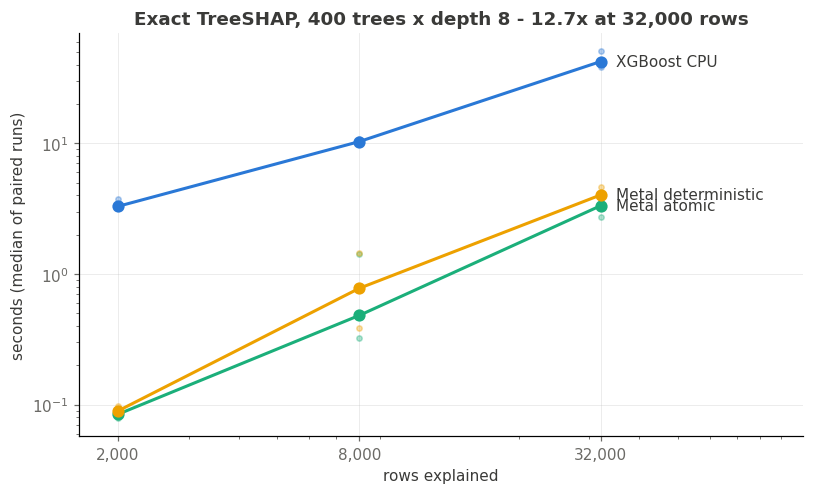

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for name, color in COLORS.items():
    rows_axis = list(results)
    medians = [float(np.median(results[r]["samples"][name])) for r in rows_axis]
    for r in rows_axis:  # raw samples: honest dispersion
        ax.plot([r] * len(results[r]["samples"][name]), results[r]["samples"][name],
                "o", color=color, ms=3.5, alpha=0.35, zorder=2)
    ax.plot(rows_axis, medians, "-o", color=color, lw=2, ms=7, zorder=3)
    ax.annotate(name, (rows_axis[-1], medians[-1]),
                xytext=(10, 0), textcoords="offset points",
                va="center", fontsize=10, color="#3a3a38")

cpu_m = float(np.median(results[ROW_COUNTS[-1]]["samples"]["XGBoost CPU"]))
gpu_m = float(np.median(results[ROW_COUNTS[-1]]["samples"]["Metal atomic"]))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(ROW_COUNTS, [f"{r:,}" for r in ROW_COUNTS])
ax.set_xlabel("rows explained")
ax.set_ylabel("seconds (median of paired runs)")
ax.set_title(f"Exact TreeSHAP, 400 trees x depth 8 - "
             f"{cpu_m / gpu_m:.1f}x at {ROW_COUNTS[-1]:,} rows")
ax.set_xlim(ROW_COUNTS[0] * 0.8, ROW_COUNTS[-1] * 3.2)
plt.tight_layout()
plt.show()

## Setup cost and break-even

The explainer's one-time compilation only pays off if it is amortized. With the
steady-state per-row costs measured above, the break-even batch size is:

In [7]:
big = ROW_COUNTS[-1]
cpu_per_row = float(np.median(results[big]["samples"]["XGBoost CPU"])) / big
gpu_per_row = float(np.median(results[big]["samples"]["Metal atomic"])) / big
break_even = setup_s / (cpu_per_row - gpu_per_row)
print(f"CPU  : {cpu_per_row * 1e6:7.1f} us/row")
print(f"Metal: {gpu_per_row * 1e6:7.1f} us/row + {setup_s:.2f} s one-time compile")
print(f"-> Metal wins end-to-end beyond ~{break_even:,.0f} rows "
      f"(or from the second batch onward on a reused explainer)")

CPU  :  1317.3 us/row
Metal:   103.9 us/row + 1.12 s one-time compile
-> Metal wins end-to-end beyond ~922 rows (or from the second batch onward on a reused explainer)


## Notes

- The committed outputs were produced on an idle M4 Max; sustained runs settle at
  lower clocks. For publication-grade numbers use the repository harnesses
  (`benchmarks/phase2_run.py`, `benchmarks/benchmark_mac.py`), which add hashing,
  power capture, and schema-validated artifacts.
- Deterministic mode trades a modest slowdown for **bit-repeatable** output — see
  [`03-accumulation-modes.ipynb`](03-accumulation-modes.ipynb).
- Correctness is asserted, not assumed: every configuration checks the elementwise
  agreement between the engines (column `max |GPU-CPU|` above, gate 1e-3, observed
  ~1e-5).